In [9]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [39]:
with open('Deterministic_results_with_start.json') as json_file:
    F_results = json.load(json_file)


In [40]:
F_results

{'W[LG_Chem,(4, 4)]': 0.0,
 'Q[M,PT_Bio,(8, 8)]': 0.0,
 'W[Xiamen_Innovax,(2, 4)]': -0.0,
 'X_tilda[DTwP,Biological_E,(10, 10)]': 69120000.0,
 'Q[TT,BB_NCIPD,(4, 4)]': 0.0,
 'Vc[M,9]': 26280000.0,
 'Vc[DT,6]': 0.0,
 'Q[Penta,Biological_E,(3, 7)]': 392444367.3506334,
 'K[HPV,GSK,(4, 6)]': 0.0,
 'W[Bharat_Biotech,(7, 7)]': 1.0,
 'X_tilda[IPV,Bilthoven,(3, 7)]': 0.0,
 'X_tilda[Rotavirus,Bharat_Biotech,(3, 3)]': 8333000.301841229,
 'W[BB_NCIPD,(1, 3)]': -0.0,
 'X_tilda[Penta,Panacea_Biotec,(2, 2)]': 5742679.2452830225,
 'Y[LG_Chem,3]': 1.0,
 'X_tilda[Penta,Biological_E,(7, 7)]': 0.0,
 'Q[Penta,Panacea_Biotec,(8, 8)]': 0.0,
 'Q[HPV,Xiamen_Innovax,(2, 2)]': 0.0,
 'K[DTwP,Biological_E,(2, 4)]': 71262293.02672513,
 'K[DT,PT_Bio,(8, 10)]': 0.0,
 'X[DT,BB_NCIPD,4]': 0.0,
 'X_tilda[Hib,Serum_Institute,(9, 9)]': 0.0,
 'X_tilda[OPV,Haffkine_Bio,(7, 7)]': 9960000.0,
 'K[Td,PT_Bio,(4, 6)]': 0.0,
 'X[Rotavirus,Serum_Institute,10]': 204600000.0,
 'X_tilda[Rotavirus,GSK,(4, 8)]': 0.0,
 'X_tilda[HepB,LG_

In [41]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [42]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


        Antigen  Year  Value
0           Hib     8    0.0
1         Mumps     2    0.0
2     Rotavirus     1    0.0
3           HPV     8    0.0
4     Rotavirus     2    0.0
..          ...   ...    ...
127   Rotavirus     5    0.0
128  Diphtheria     2    0.0
129   Rotavirus     6    0.0
130         PCV    10    0.0
131     Rubella    10    0.0

[132 rows x 3 columns]


In [43]:
import pandas as pd

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Grouping and counting
result = df.groupby(['Antigen', 'Year'])['Value'].sum().reset_index()
result = result[result['Value'] != 0.0]

# Grouping by Antigen and summing the Value column
# result = df.groupby('Antigen')['Value'].sum().reset_index()

# Displaying the result
print(result)


   Antigen  Year         Value
12     HPV     1  7.149793e+06
13     HPV     2  2.707061e+07
14     HPV     3  5.923061e+07
15     HPV     4  1.448898e+08
16     HPV     5  2.544798e+08
56   Mumps     1  3.133686e+06


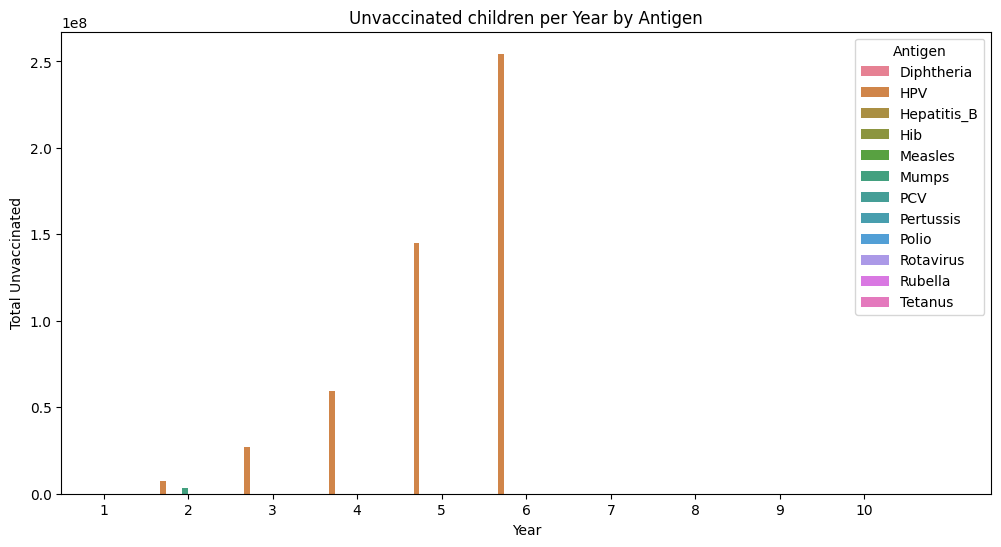

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 11))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result)
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.savefig('unvax_childred_with_start.png')
plt.show()


## Unvaccinated children without starting point

In [24]:
with open('Deterministic_results.json') as json_file:
    Q_results_clean = json.load(json_file)

In [37]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in Q_results_clean.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})

NameError: name 'Q_results_clean' is not defined

In [38]:
grouped_results

{'S[': []}

In [27]:

# Extracting data into lists
antigen_list = []
year_list = []
value_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Extracting Antigen and Year from the key
        antigen = key.split(',')[0][2:]
        year = int(key.split(',')[1][:-1])
        
        # Appending values to lists
        antigen_list.append(antigen)
        year_list.append(year)
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list
})

# Displaying the DataFrame
print(df)


        Antigen  Year  Value
0       Tetanus     6    0.0
1           HPV     2    0.0
2     Pertussis     0    0.0
3           HPV     5    0.0
4    Diphtheria     3    0.0
..          ...   ...    ...
127       Mumps     3    0.0
128     Measles     9    0.0
129  Diphtheria     0    0.0
130         Hib     0    0.0
131         PCV     2    0.0

[132 rows x 3 columns]


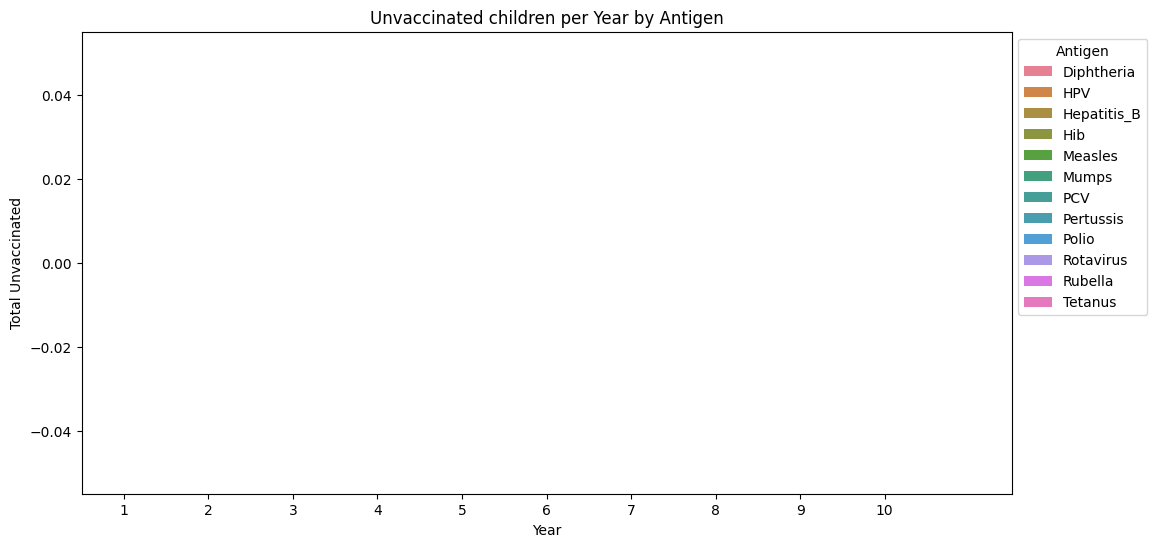

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame
# If not, replace df with your DataFrame variable name

# Create a list of all years from 1 to 10
all_years = list(range(1, 11))

# Grouping by Year, Antigen, and summing the Value column
result = df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()

# Filling missing combinations of Year and Antigen with 0.0 value
result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

# Melt the DataFrame to have a long format suitable for plotting
result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

# Plotting the bar chart with seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='Year', y='Value', hue='Antigen', data=result)
plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
plt.xlabel('Year')
plt.ylabel('Total Unvaccinated')
plt.title('Unvaccinated children per Year by Antigen')
plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
plt.savefig('unvax_childred_without_start.png')
plt.show()
